# 04 – Feature Engineering

This notebook aims to:
1. **Baseline Features** – Total clicks, active days, most recent interaction, early engagement, submission delay, average score, and learning stability.
2. **Composite Behavioral Features** – Engagement Intensity, Assessment Discipline, Persistence Score, and Learning Risk Index.
3. **Standardize and select the final feature sets** for Segmentation, Prediction, and Recommendation.

---
**Input:** `data/processed/` (cleaned files from step 02)  
**Output:** `data/processed/features_final.csv`

In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from scipy.stats import skew

pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', 50)

PROCESSED = '../data/processed/'
OBSERVATION_WINDOW = 30
EARLY_ENGAGEMENT_WINDOW = 14
AT_RISK_OUTCOMES = ['Fail', 'Withdrawn']
print('Libraries loaded ✓')

Libraries loaded ✓


## 1. Load Processed Data

In [2]:
KEY = ['id_student', 'code_module', 'code_presentation']

# --- Load core tables ---
student_info    = pd.read_csv(PROCESSED + 'student_info_clean.csv', low_memory=False)
vle_window_feat = pd.read_csv(PROCESSED + '_eda_vle_window_features.csv', low_memory=False)
vle_summary     = pd.read_csv(PROCESSED + 'student_vle_summary.csv', low_memory=False)
assess_perf     = pd.read_csv(PROCESSED + 'assessment_performance.csv', low_memory=False)
assess_meta     = pd.read_csv(PROCESSED + 'assessments_clean.csv', low_memory=False)
registration    = pd.read_csv(PROCESSED + 'student_registration_clean.csv', low_memory=False)

print('student_info    :', student_info.shape)
print('vle_window_feat :', vle_window_feat.shape)
print('vle_summary     :', vle_summary.shape)
print('assess_perf     :', assess_perf.shape)
print('assess_meta     :', assess_meta.shape)
print('registration    :', registration.shape)

student_info    : (32593, 12)
vle_window_feat : (29228, 11)
vle_summary     : (29228, 8)
assess_perf     : (173912, 10)
assess_meta     : (206, 6)
registration    : (32593, 5)


---
## 2. Baseline Features

| Feature | Description |
|---|---|
| `total_clicks` | Total number of VLE clicks observed up to day 30 |
| `active_days` | Number of active days observed up to day 30 |
| `days_since_last` | Gap between the last active day and the day-30 cutoff |
| `early_engagement` | Total clicks in the first 14 days |
| `early_engagement_ratio` | Ratio of first-14-day clicks to clicks observed up to day 30 |
| `avg_submission_delay` | Average (deadline − submission date) for submissions recorded by day 30 |
| `avg_score` | Weighted average score for submissions recorded by day 30 |
| `score_std` | Standard deviation of scores – a proxy for learning stability |

### 2.1 VLE-Based Features from `_eda_vle_window_features` and `vle_summary`

In [3]:
# Use cached 30-day counts from notebook 03 plus the enrollment-level VLE summary
# to rebuild leakage-safe timing proxies inside the day-30 observation window.
vle_features = vle_window_feat[
    [
        'id_student', 'code_module', 'code_presentation',
        'clicks_30d', 'active_days_30', 'clicks_14d',
        'active_days_14', 'pre_start_active_days', 'total_active_days'
    ]
].copy()

vle_features.rename(columns={
    'clicks_30d': 'total_clicks',
    'active_days_30': 'active_days',
    'clicks_14d': 'early_engagement',
}, inplace=True)

vle_timing = vle_summary[KEY + ['first_activity_date', 'last_activity_date']].rename(columns={
    'first_activity_date': 'global_first_activity_date',
    'last_activity_date': 'global_last_activity_date',
})
vle_features = vle_features.merge(vle_timing, on=KEY, how='left')

vle_features['late_window_active_days'] = (
    vle_features['active_days'] - vle_features['active_days_14']
).clip(lower=0)

vle_features['post_30_active_days'] = (
    vle_features['total_active_days'] - vle_features['pre_start_active_days'] - vle_features['active_days']
).clip(lower=0)

def expected_min_day(num_days, start_day, window_size):
    return start_day + ((window_size + 1) / (num_days + 1)) - 1

def expected_max_day(num_days, start_day, window_size):
    return start_day + (num_days * (window_size + 1) / (num_days + 1)) - 1

vle_features['first_activity_date_proxy'] = -1.0
exact_first_mask = (
    (vle_features['active_days'] > 0) &
    (vle_features['pre_start_active_days'] == 0) &
    vle_features['global_first_activity_date'].between(0, OBSERVATION_WINDOW)
)
vle_features.loc[exact_first_mask, 'first_activity_date_proxy'] = vle_features.loc[exact_first_mask, 'global_first_activity_date']

early_activity_mask = (
    (vle_features['first_activity_date_proxy'] < 0) &
    (vle_features['active_days_14'] > 0)
)
vle_features.loc[early_activity_mask, 'first_activity_date_proxy'] = expected_min_day(
    vle_features.loc[early_activity_mask, 'active_days_14'],
    start_day=0,
    window_size=15,
)

late_only_mask = (
    (vle_features['first_activity_date_proxy'] < 0) &
    (vle_features['late_window_active_days'] > 0)
)
vle_features.loc[late_only_mask, 'first_activity_date_proxy'] = expected_min_day(
    vle_features.loc[late_only_mask, 'late_window_active_days'],
    start_day=15,
    window_size=16,
)

vle_features['last_activity_date_proxy'] = -1.0
exact_last_mask = (
    (vle_features['active_days'] > 0) &
    (vle_features['post_30_active_days'] == 0) &
    vle_features['global_last_activity_date'].between(0, OBSERVATION_WINDOW)
)
vle_features.loc[exact_last_mask, 'last_activity_date_proxy'] = vle_features.loc[exact_last_mask, 'global_last_activity_date']

late_window_mask = (
    (vle_features['last_activity_date_proxy'] < 0) &
    (vle_features['late_window_active_days'] > 0)
)
vle_features.loc[late_window_mask, 'last_activity_date_proxy'] = expected_max_day(
    vle_features.loc[late_window_mask, 'late_window_active_days'],
    start_day=15,
    window_size=16,
)

early_only_mask = (
    (vle_features['last_activity_date_proxy'] < 0) &
    (vle_features['active_days_14'] > 0)
)
vle_features.loc[early_only_mask, 'last_activity_date_proxy'] = expected_max_day(
    vle_features.loc[early_only_mask, 'active_days_14'],
    start_day=0,
    window_size=15,
)

for col in ['first_activity_date_proxy', 'last_activity_date_proxy']:
    vle_features[col] = np.where(
        vle_features[col] >= 0,
        np.clip(np.rint(vle_features[col]), 0, OBSERVATION_WINDOW),
        -1,
    )

vle_features['days_since_last'] = np.where(
    vle_features['last_activity_date_proxy'] >= 0,
    OBSERVATION_WINDOW - vle_features['last_activity_date_proxy'],
    OBSERVATION_WINDOW + 1,
)

# Keep sentinel values for enrollments with no observed activity by day 30.
vle_features.rename(columns={
    'first_activity_date_proxy': 'first_activity_date',
    'last_activity_date_proxy': 'last_activity_date',
}, inplace=True)

vle_features = vle_features[
    KEY + ['total_clicks', 'active_days', 'days_since_last', 'early_engagement', 'last_activity_date', 'first_activity_date']
]

print('vle_features :', vle_features.shape)

vle_features : (29228, 9)


### 2.2 Assessment-based features

In [4]:
# Join assessment submissions with metadata to get the original deadlines
assess = assess_perf.merge(
    assess_meta[['id_assessment', 'date']], # weight is already in assess_perf
    on='id_assessment',
    how='left',
    suffixes=('', '_meta') # in case of overlap
)

# Exclude banked entries and missing deadlines / sub dates
assess = assess[(assess['is_banked'] == 0) & assess['date'].notna() & assess['date_submitted'].notna()].copy()
assess['date'] = assess['date'].astype(float)
assess['date_submitted'] = assess['date_submitted'].astype(float)

# Filter for submissions physically made before or on day 30
assess_window = assess[assess['date_submitted'] <= OBSERVATION_WINDOW].copy()

# ── submission_delay: positive = submitted early, negative = late
assess_window['submission_delay'] = assess_window['date'] - assess_window['date_submitted']

avg_delay = (
    assess_window
    .groupby(KEY, as_index=False)['submission_delay']
    .mean()
    .rename(columns={'submission_delay': 'avg_submission_delay'})
)

# ── weighted average score up to day 30 ──────────────────────────────────────
assess_window['weighted_score'] = assess_window['score'] * assess_window['weight'].fillna(10) # fill na weight with some default
assess_window['weight_filled']  = assess_window['weight'].fillna(10)

weighted_score = (
    assess_window
    .groupby(KEY)
    .apply(lambda g: g['weighted_score'].sum() / g['weight_filled'].sum() if g['weight_filled'].sum() > 0 else 0)
    .reset_index(name='avg_score')
)

# ── score_std – learning stability up to day 30 ──────────────────────────────
score_std = (
    assess_window
    .groupby(KEY, as_index=False)['score']
    .std()
    .rename(columns={'score': 'score_std'})
)
score_std['score_std'] = score_std['score_std'].fillna(0)  # only 1 assessment → 0

print('avg_delay    :', avg_delay.shape)
print('weighted_score:', weighted_score.shape)
print('score_std    :', score_std.shape)

avg_delay    : (20790, 4)
weighted_score: (20790, 4)
score_std    : (20790, 4)


### 2.3 Merge baseline features

In [5]:
# Start from the enrollment-level student_info table (one row per student-course-presentation)
features = student_info[KEY + ['gender', 'region', 'highest_education',
                                'imd_band', 'age_band', 'num_of_prev_attempts',
                                'studied_credits', 'disability', 'final_result']].copy()

for df in [vle_features, avg_delay, weighted_score, score_std]:
    features = features.merge(df, on=KEY, how='left')

# early_engagement_ratio = clicks in the first 14 days / clicks observed by day 30
features['early_engagement']       = features['early_engagement'].fillna(0)
features['early_engagement_ratio'] = (
    features['early_engagement'] / features['total_clicks'].replace(0, np.nan)
).clip(upper=1).fillna(0)

print('Merged feature matrix:', features.shape)
features[['total_clicks','active_days','days_since_last','early_engagement',
           'early_engagement_ratio','avg_submission_delay','avg_score','score_std']].describe()

Merged feature matrix: (32593, 22)


,total_clicks,active_days,days_since_last,early_engagement,early_engagement_ratio,avg_submission_delay,avg_score,score_std
count,29228.0000,29228.0000,29228.0000,32593.0000,32593.0000,20790.0000,20790.0000,20790.0000
mean,288.4842,11.3483,4.8861,124.1787,0.4261,11.7705,67.6698,1.2544
std,352.2948,7.9162,7.9458,183.0584,0.3093,35.1823,26.6898,4.0642
min,0.0000,0.0000,0.0000,0.0000,0.0000,-18.0000,0.0000,0.0000
25%,65.0000,5.0000,1.0000,8.0000,0.1500,0.0000,60.0000,0.0000
50%,180.0000,10.0000,2.0000,61.0000,0.4364,1.0000,75.0000,0.0000
75%,386.0000,17.0000,5.0000,167.0000,0.6433,3.0000,86.0000,0.0000
max,6571.0000,31.0000,31.0000,4733.0000,1.0000,242.0000,100.0000,56.5685


---
## 3. Composite Behavioral Features

| Feature | Formula / Meaning |
|---|---|
| `engagement_intensity` | Average clicks per active day |
| `assessment_discipline` | Composite score based on delay + submission completion |
| `persistence_score` | Share of the observed day-30 activity span in which the learner was active |
| `learning_risk_index` | Composite risk index (0–1, higher = higher risk) |

In [6]:
# ── 3.1 Engagement Intensity ─────────────────────────────────────────────────
# clicks per active day
features['engagement_intensity'] = (
    features['total_clicks'] / features['active_days'].replace(0, np.nan)
).fillna(0)

In [7]:
# ── 3.2 Assessment Discipline ────────────────────────────────────────────────
# Count submitted assessments per student-course up to day 30
submitted_count = (
    assess_window
    .groupby(KEY, as_index=False)['id_assessment']
    .count()
    .rename(columns={'id_assessment': 'num_submitted'})
)

# Count assessments whose deadline is available by day 30
assess_meta_window = assess_meta[assess_meta['date'].fillna(np.inf) <= OBSERVATION_WINDOW].copy()
total_assess = (
    assess_meta_window
    .groupby(['code_module', 'code_presentation'], as_index=False)['id_assessment']
    .count()
    .rename(columns={'id_assessment': 'num_total_assessments'})
)

features = features.merge(submitted_count, on=KEY, how='left')
features = features.merge(total_assess, on=['code_module', 'code_presentation'], how='left')
features['num_submitted'] = features['num_submitted'].fillna(0)
features['num_total_assessments'] = features['num_total_assessments'].fillna(0)

# Completion ratio within the observation window
features['completion_ratio'] = (
    features['num_submitted'] / features['num_total_assessments'].replace(0, np.nan)
).clip(0, 1).fillna(0)

# Normalise delay to [0,1] – higher = more disciplined (submitted earlier)
# Missing delay means no observed submission, so we score it as the weakest case.
delay_non_null = features['avg_submission_delay'].dropna()
delay_min = delay_non_null.min() if not delay_non_null.empty else 0
delay_max = delay_non_null.max() if not delay_non_null.empty else delay_min
delay_range = delay_max - delay_min if delay_max != delay_min else 1
delay_vals = features['avg_submission_delay'].fillna(delay_min)
features['delay_norm'] = ((delay_vals - delay_min) / delay_range).clip(0, 1)
features.loc[features['num_submitted'] == 0, 'delay_norm'] = 0

# assessment_discipline = 0.5*completion_ratio + 0.5*delay_norm
features['assessment_discipline'] = (
    0.5 * features['completion_ratio'] + 0.5 * features['delay_norm']
)

In [8]:
# ── 3.3 Persistence Score ────────────────────────────────────────────────────
# = proportion of the observed day-30 activity span in which the student was active.
# Timing fields above are already rebuilt from dates between day 0 and day 30 only.

valid_activity_window = (
    (features['first_activity_date'] >= 0) &
    (features['last_activity_date'] >= 0)
)

features['activity_span'] = 0
features.loc[valid_activity_window, 'activity_span'] = (
    features.loc[valid_activity_window, 'last_activity_date'] -
    features.loc[valid_activity_window, 'first_activity_date'] + 1
).clip(lower=1)

features['persistence_score'] = 0.0
features.loc[valid_activity_window, 'persistence_score'] = (
    features.loc[valid_activity_window, 'active_days'] /
    features.loc[valid_activity_window, 'activity_span'].replace(0, np.nan)
).clip(0, 1).fillna(0)

In [9]:
# ── 3.4 Learning Risk Index ──────────────────────────────────────────────────
# Composite risk score (higher → more at risk)
#   Component 1: low engagement   → 1 - engagement_norm
#   Component 2: low score        → 1 - score_norm
#   Component 3: low persistence  → 1 - persistence_score
#   Component 4: low discipline   → 1 - assessment_discipline
#   Component 5: late submission  → 1 - delay_norm

def minmax_norm(series):
    mn, mx = series.min(), series.max()
    return (series - mn) / (mx - mn) if mx != mn else pd.Series(0.5, index=series.index)

eng_norm   = minmax_norm(features['total_clicks'].fillna(0))
score_norm = minmax_norm(features['avg_score'].fillna(0))

# Early engagement ratio as an additional signal
early_norm = minmax_norm(features['early_engagement_ratio'].fillna(0))

features['learning_risk_index'] = (
    0.25 * (1 - eng_norm) +
    0.30 * (1 - score_norm) +
    0.20 * (1 - features['persistence_score']) +
    0.15 * (1 - features['assessment_discipline']) +
    0.10 * (1 - early_norm)
).round(4)

print('Composite features added. Shape:', features.shape)

Composite features added. Shape: (32593, 31)


---
## 4. Standardization and Final Feature Selection

All behavioral and assessment features below are constrained to information available by day 30 to reduce data leakage.
Since the downstream tasks differ, the feature sets also differ slightly:

| Target | Main Feature Set |
|---|---|
| **Segmentation** | Continuous features standardized with StandardScaler |
| **Prediction (at-risk)** | All features + one-hot categoricals + composite features |
| **Recommendation** | Engagement + performance + discipline |

### 4.1 Handle Missing Values

In [10]:
# Use explicit defaults for timing fields so "no observed activity" is not
# mistaken for perfectly recent activity.
fill_defaults = {
    'first_activity_date': -1,
    'last_activity_date': -1,
    'days_since_last': OBSERVATION_WINDOW + 1,
    'activity_span': 0,
    'num_total_assessments': 0,
}
for col, value in fill_defaults.items():
    features[col] = features[col].fillna(value)

num_zero_fill_cols = [
    'total_clicks', 'active_days',
    'early_engagement', 'early_engagement_ratio',
    'avg_submission_delay', 'avg_score', 'score_std',
    'engagement_intensity', 'assessment_discipline',
    'persistence_score', 'learning_risk_index',
    'num_submitted', 'completion_ratio', 'delay_norm'
]

for col in num_zero_fill_cols:
    features[col] = features[col].fillna(0)

# Categorical columns – fill with 'Unknown'
cat_cols = ['gender', 'region', 'highest_education', 'imd_band', 'age_band', 'disability']
for col in cat_cols:
    features[col] = features[col].fillna('Unknown')

missing_pct = features.isnull().mean() * 100
print('Missing % after imputation:')
print(missing_pct[missing_pct > 0].to_string() if missing_pct[missing_pct > 0].any() else '  None ✓')

Missing % after imputation:
  None ✓


### 4.2 Distribution and Log Transform for Skewed Features

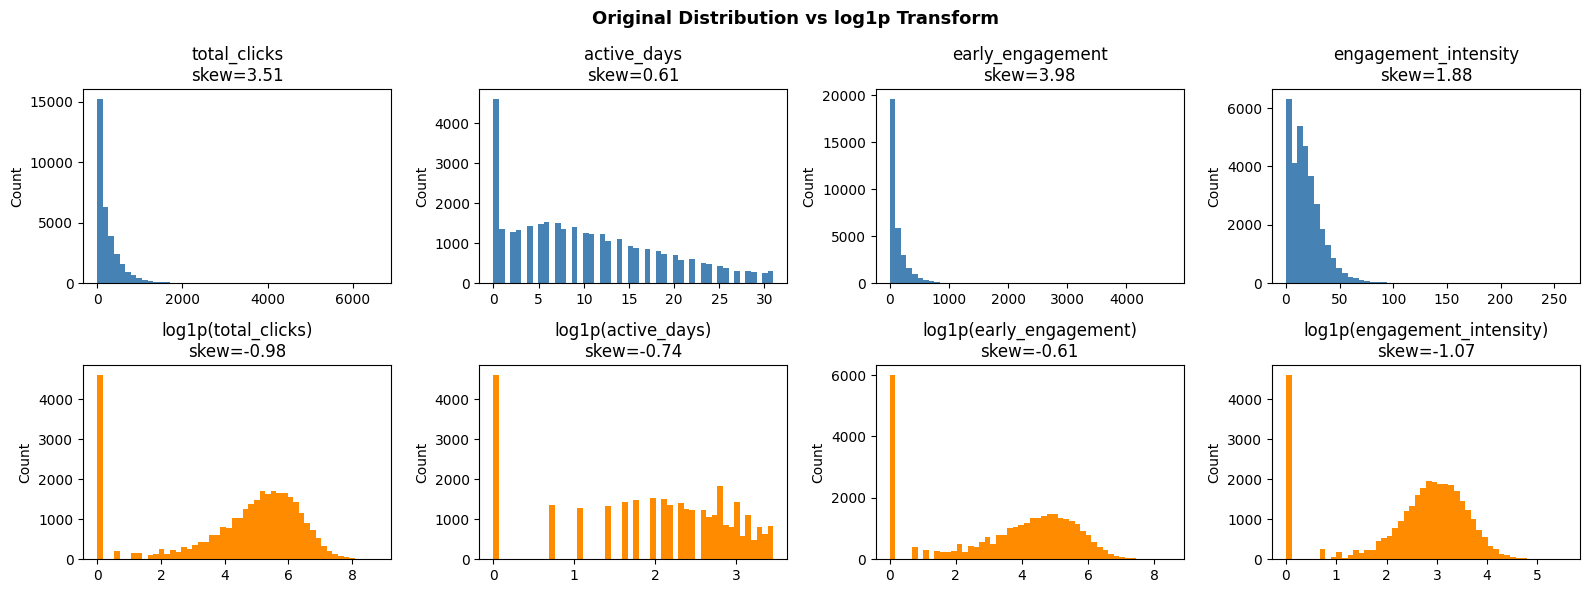

In [11]:
skew_cols = ['total_clicks', 'active_days', 'early_engagement', 'engagement_intensity']

fig, axes = plt.subplots(2, len(skew_cols), figsize=(16, 6))
for i, col in enumerate(skew_cols):
    axes[0, i].hist(features[col], bins=50, color='steelblue', edgecolor='none')
    axes[0, i].set_title(f'{col}\nskew={skew(features[col]):.2f}')
    axes[0, i].set_ylabel('Count')

    log_vals = np.log1p(features[col])
    axes[1, i].hist(log_vals, bins=50, color='darkorange', edgecolor='none')
    axes[1, i].set_title(f'log1p({col})\nskew={skew(log_vals):.2f}')
    axes[1, i].set_ylabel('Count')

plt.suptitle('Original Distribution vs log1p Transform', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [12]:
# Apply log1p to heavily skewed VLE click columns
for col in skew_cols:
    features[f'{col}_log'] = np.log1p(features[col])

print('Log-transformed columns added.')

Log-transformed columns added.


### 4.3 Feature Set for Segmentation (StandardScaler)

In [13]:
seg_features = [
    'total_clicks_log',
    'active_days_log',
    'early_engagement_log',
    'early_engagement_ratio',
    'avg_score',
    'score_std',
    'avg_submission_delay',
    'engagement_intensity_log',
    'assessment_discipline',
    'persistence_score',
    'learning_risk_index',
]

seg_df = features[KEY + seg_features].copy()

scaler_seg = StandardScaler()
seg_df_scaled = seg_df.copy()
seg_df_scaled[seg_features] = scaler_seg.fit_transform(seg_df[seg_features])

print('Segmentation feature matrix (scaled):', seg_df_scaled.shape)
seg_df_scaled[seg_features].describe().round(3)

Segmentation feature matrix (scaled): (32593, 14)


,total_clicks_log,active_days_log,early_engagement_log,early_engagement_ratio,avg_score,score_std,avg_submission_delay,engagement_intensity_log,assessment_discipline,persistence_score,learning_risk_index
count,32593.0000,32593.0000,32593.0000,32593.0000,32593.0000,32593.0000,32593.0000,32593.0000,32593.0000,32593.0000,32593.0000
mean,0.0000,0.0000,0.0000,-0.0000,0.0000,-0.0000,-0.0000,0.0000,0.0000,0.0000,0.0000
std,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
min,-2.0230,-1.9130,-1.7120,-1.3780,-1.1100,-0.2420,-0.8900,-2.0970,-1.0650,-1.4980,-3.0030
25%,-0.3680,-0.5900,-0.6490,-0.8930,-1.1100,-0.2420,-0.2620,-0.2630,-1.0650,-0.6840,-0.8280
50%,0.3090,0.2840,0.2840,0.0330,0.3610,-0.2420,-0.2620,0.2730,0.1200,-0.0920,-0.1970
75%,0.7100,0.7900,0.7670,0.7020,0.9470,-0.2420,-0.2100,0.6700,1.1560,0.6500,0.8740
max,2.0690,1.3930,2.3810,1.8550,1.4620,16.8930,8.1810,2.5510,3.0970,2.0820,1.5660


### 4.4 Feature Set for Prediction (At-Risk Modeling)

In [14]:
# One-hot encode categoricals
cat_encode_cols = ['gender', 'highest_education', 'imd_band', 'age_band', 'disability']
cat_encoded = pd.get_dummies(features[cat_encode_cols], drop_first=True, dtype=int)

pred_num_features = [
    'total_clicks_log', 'active_days_log', 'early_engagement_log',
    'early_engagement_ratio', 'days_since_last',
    'avg_score', 'score_std', 'avg_submission_delay',
    'engagement_intensity_log', 'assessment_discipline',
    'persistence_score', 'learning_risk_index',
    'num_of_prev_attempts', 'studied_credits',
    'num_submitted', 'completion_ratio',
]

# Binary target: 1 = at risk (Fail or Withdrawn), 0 = not at risk
features['at_risk'] = features['final_result'].isin(AT_RISK_OUTCOMES).astype(int)

pred_df = pd.concat([
    features[KEY + pred_num_features + ['at_risk']].reset_index(drop=True),
    cat_encoded.reset_index(drop=True)
], axis=1)

print('Prediction feature matrix:', pred_df.shape)
print('At-risk distribution:')
print(pred_df['at_risk'].value_counts(normalize=True).rename({0: 'Not at risk', 1: 'At risk'}).round(3))

Prediction feature matrix: (32593, 38)
At-risk distribution:
at_risk
At risk       0.5280
Not at risk   0.4720
Name: proportion, dtype: float64


### 4.5 Feature Set for Recommendation

In [15]:
rec_features = [
    'total_clicks_log',
    'early_engagement_ratio',
    'engagement_intensity_log',
    'avg_score',
    'completion_ratio',
    'assessment_discipline',
    'persistence_score',
    'learning_risk_index',
]

rec_df = features[KEY + rec_features + ['final_result', 'at_risk']].copy()

# MinMax scale for recommendation (distances / similarity)
scaler_rec = MinMaxScaler()
rec_df[rec_features] = scaler_rec.fit_transform(rec_df[rec_features])

print('Recommendation feature matrix (MinMax scaled):', rec_df.shape)

Recommendation feature matrix (MinMax scaled): (32593, 13)


---
## 5. Inspect Composite Feature Distributions

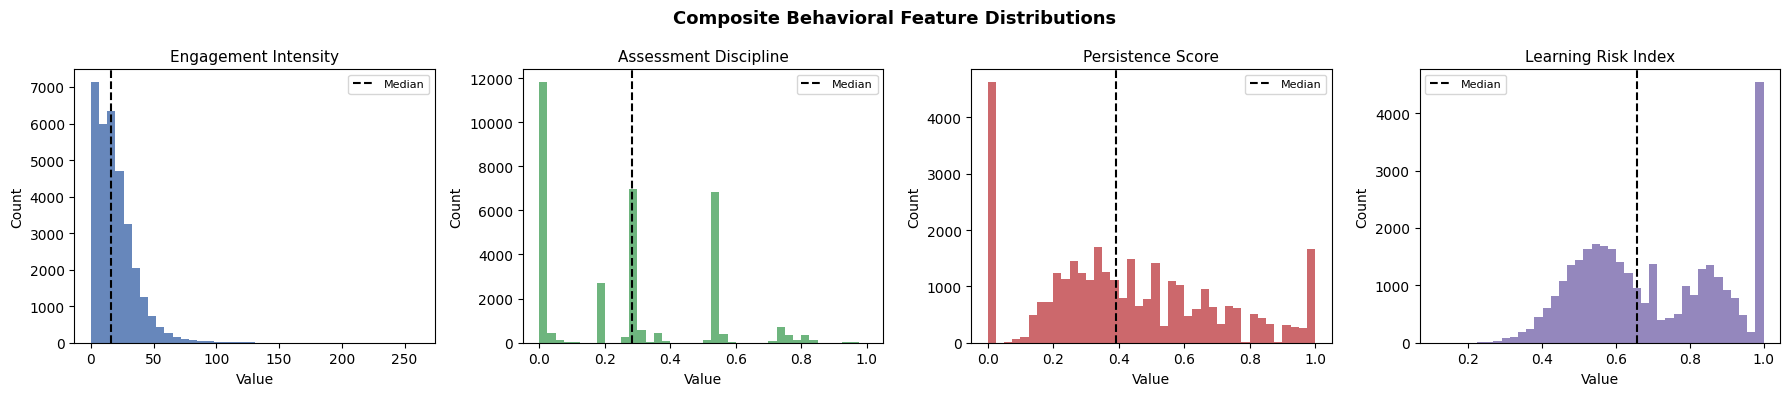

In [16]:
composite_cols = [
    'engagement_intensity', 'assessment_discipline',
    'persistence_score', 'learning_risk_index'
]

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
palette = ['#4C72B0', '#55A868', '#C44E52', '#8172B2']

for ax, col, color in zip(axes, composite_cols, palette):
    ax.hist(features[col], bins=40, color=color, edgecolor='none', alpha=0.85)
    ax.axvline(features[col].median(), color='black', linestyle='--', linewidth=1.5, label='Median')
    ax.set_title(col.replace('_', ' ').title(), fontsize=11)
    ax.set_xlabel('Value')
    ax.set_ylabel('Count')
    ax.legend(fontsize=8)

plt.suptitle('Composite Behavioral Feature Distributions', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

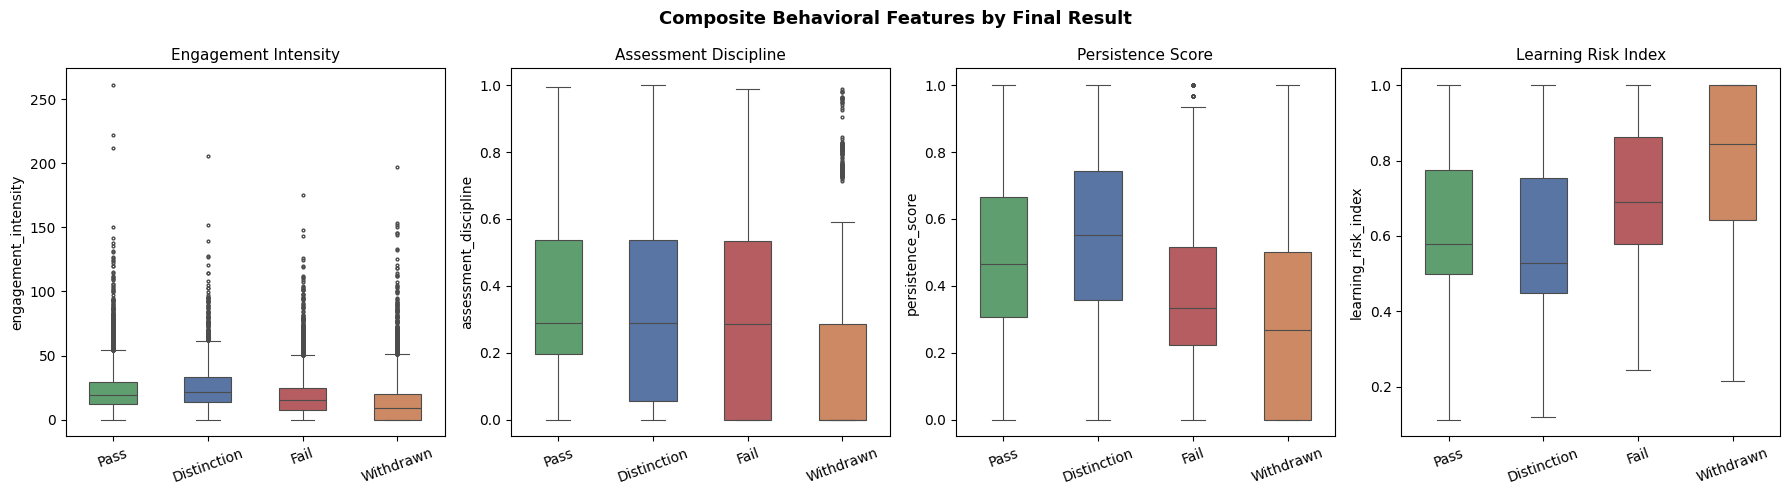

In [17]:
# Boxplot by final_result
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
result_order = ['Pass', 'Distinction', 'Fail', 'Withdrawn']
palette_box = {'Pass': '#55A868', 'Distinction': '#4C72B0', 'Fail': '#C44E52', 'Withdrawn': '#DD8452'}

plot_df = features[composite_cols + ['final_result']].copy()
plot_df = plot_df[plot_df['final_result'].isin(result_order)]

for ax, col in zip(axes, composite_cols):
    sns.boxplot(
        data=plot_df, x='final_result', y=col,
        order=result_order, palette=palette_box,
        ax=ax, width=0.5, linewidth=0.8, fliersize=2
    )
    ax.set_title(col.replace('_', ' ').title(), fontsize=11)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=20)

plt.suptitle('Composite Behavioral Features by Final Result', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 5.1 Correlation Heatmap (Segmentation Feature Set)

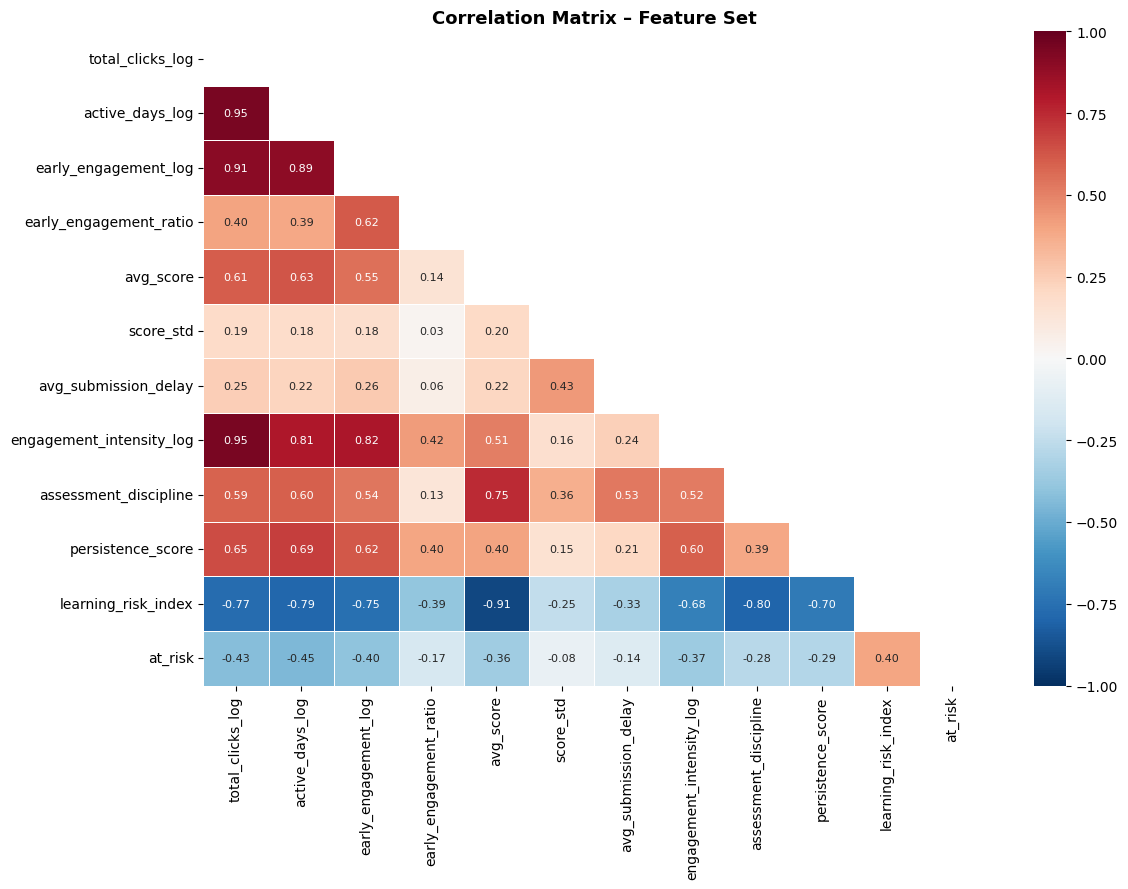

In [18]:
corr = features[seg_features + ['at_risk']].corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
    center=0, linewidths=0.4, ax=ax,
    annot_kws={'size': 8}, vmin=-1, vmax=1
)
ax.set_title('Correlation Matrix – Feature Set', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 6. Save Outputs

In [19]:
# ── Full feature table (raw + composite + log-transformed)
all_feature_cols = KEY + [
    'gender', 'region', 'highest_education', 'imd_band', 'age_band',
    'num_of_prev_attempts', 'studied_credits', 'disability',
    'final_result', 'at_risk',
    # Baseline
    'total_clicks', 'active_days', 'last_activity_date', 'days_since_last',
    'first_activity_date', 'activity_span',
    'early_engagement', 'early_engagement_ratio',
    'avg_submission_delay', 'avg_score', 'score_std',
    'num_submitted', 'num_total_assessments', 'completion_ratio', 'delay_norm',
    # Log-transformed
    'total_clicks_log', 'active_days_log',
    'early_engagement_log', 'engagement_intensity_log',
    # Composite
    'engagement_intensity', 'assessment_discipline',
    'persistence_score', 'learning_risk_index',
]

features_final = features[all_feature_cols].copy()
features_final.to_csv(PROCESSED + 'features_final.csv', index=False)

# ── Segmentation subset (scaled)
seg_df_scaled.to_csv(PROCESSED + 'features_segmentation.csv', index=False)

# ── Prediction subset
pred_df.to_csv(PROCESSED + 'features_prediction.csv', index=False)

# ── Recommendation subset (scaled)
rec_df.to_csv(PROCESSED + 'features_recommendation.csv', index=False)

print('Saved:')
print(f'  features_final.csv        → {features_final.shape}')
print(f'  features_segmentation.csv → {seg_df_scaled.shape}')
print(f'  features_prediction.csv   → {pred_df.shape}')
print(f'  features_recommendation.csv → {rec_df.shape}')

Saved:
  features_final.csv        → (32593, 36)
  features_segmentation.csv → (32593, 14)
  features_prediction.csv   → (32593, 38)
  features_recommendation.csv → (32593, 13)


---
## 7. Feature Engineering Summary

| Group | Features | Used For |
|---|---|---|
| **Baseline – VLE** | `total_clicks`, `active_days`, `days_since_last`, `early_engagement`, `early_engagement_ratio` | Seg / Pred / Rec |
| **Baseline – Assessment** | `avg_submission_delay`, `avg_score`, `score_std`, `completion_ratio` | Seg / Pred / Rec |
| **Composite** | `engagement_intensity` | Seg / Pred / Rec |
| **Composite** | `assessment_discipline` | Seg / Pred / Rec |
| **Composite** | `persistence_score` | Seg / Pred / Rec |
| **Composite** | `learning_risk_index` | Pred / Rec |
| **Categorical** | `gender`, `highest_education`, `imd_band`, `age_band`, `disability` | Pred |

**Leakage control:** All behavior and assessment features were computed at the enrollment grain using information available by day 30 only. Activity recency and span use exact within-window dates when no outside-window activity exists; otherwise they fall back to window-count timing proxies derived from notebook 03 summaries, which avoids future-click leakage while keeping the pipeline runnable in the current workspace.

**Output files:**
- `features_final.csv` – complete feature table (unscaled, used as the reference dataset)
- `features_segmentation.csv` – StandardScaler output for clustering (notebook 05)
- `features_prediction.csv` – one-hot encoded categoricals for the at-risk model (notebook 06)
- `features_recommendation.csv` – MinMaxScaler output for recommendation (notebook 05)